# 📊 **APE 011 – Inferencia Estadística Multigrupo: Análisis de Varianza (ANOVA de 1 factor) y Pruebas Post-Hoc (Tukey)**

**Dataset:** Remuneraciones e Ingresos Adicionales — Municipio de Loja
- Link del municipio de Loja: https://www.loja.gob.ec/contenido/2023-lotaip
- Enlace dataset (Google Drive): https://docs.google.com/spreadsheets/d/1ERWZnpgxC-Ffaj-sxMB5El0sgge_QX4g/edit?usp=drive_link

**Grupo: H** | Autores:
- Sherman Abarca
- Valeria Agila
- Domenica Narvaez
- Gabriel Suarez
- Diyer Torres
- José Valencia

---
## 📐 **Tarea 1** — Prueba de Hipótesis para Dos Muestras Independientes ($A/B$ Testing)

* El objetivo es probar si las medias de dos poblaciones distintas y completamente independientes son iguales. Esto se plantea formalmente mediante la hipótesis nula $H_{0}:\mu_{1}=\mu_{2}$ o, de forma equivalente, $H_{0}:\mu_{1}-\mu_{2}=0$.
* **Estadístico T (asumiendo varianzas iguales):** Si se asume que ambas poblaciones comparten la misma varianza, se utiliza el estadístico T clásico:
  
  $$T=\frac{\overline{X}_{1}-\overline{X}_{2}}{S_{p}\sqrt{\frac{1}{n_{1}}+\frac{1}{n_{2}}}}$$

* **Escenario Práctico:** Se presenta un problema de ingeniería de software donde se busca verificar si un "Algoritmo A" consume menos memoria RAM que un "Algoritmo B". Para ello, se ejecutan ambos algoritmos de manera controlada en entornos aislados y se registra su consumo individual en MB.


--- A/B Testing: Algoritmo A vs Algoritmo B ---
Media Algo A: 118.91 MB | Media Algo B: 126.71 MB
Estadístico T: -2.5362
Valor-p: 1.3347e-02
Conclusión: Se RECHAZA H0. Existe una diferencia significativa en el consumo de memoria.


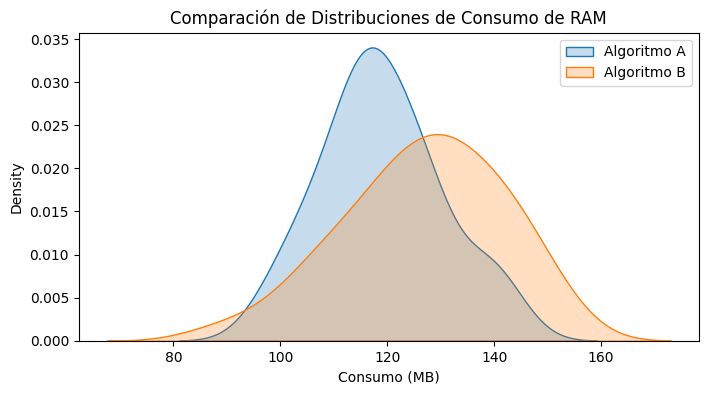

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Datos empíricos (Consumo de RAM en MB)
np.random.seed(42)
memoria_algo_A = np.random.normal(loc=120.5, scale=12.0, size=35)
memoria_algo_B = np.random.normal(loc=128.2, scale=15.0, size=40)

alpha = 0.05

# Ejecución de la prueba T para muestras independientes (2 colas)
stat_ind, p_val_ind = ttest_ind(memoria_algo_A, memoria_algo_B,
equal_var=True)

print("--- A/B Testing: Algoritmo A vs Algoritmo B ---")
print(f"Media Algo A: {np.mean(memoria_algo_A):.2f} MB | Media Algo B: {np.mean(memoria_algo_B):.2f} MB")
print(f"Estadístico T: {stat_ind:.4f}")
print(f"Valor-p: {p_val_ind:.4e}")

if p_val_ind < alpha:
    print("Conclusión: Se RECHAZA H0. Existe una diferencia significativa en el consumo de memoria.")
else:
    print("Conclusión: NO se rechaza H0. No hay evidencia de que los algoritmos difieran en consumo.")

# Visualización
plt.figure(figsize=(8, 4))
sns.kdeplot(memoria_algo_A, fill=True, label="Algoritmo A")
sns.kdeplot(memoria_algo_B, fill=True, label="Algoritmo B")
plt.title("Comparación de Distribuciones de Consumo de RAM")
plt.xlabel("Consumo (MB)")
plt.legend()
plt.show()

---

## **Tarea 2:** Prueba de Hipótesis para Muestras Pareadas (Dependientes)

* Se utiliza estrictamente cuando los datos de ambos grupos evaluados provienen de las mismas unidades de observación. Un caso típico en ingeniería es comparar las métricas de rendimiento de un mismo sistema en un estado "Antes" y "Después" de aplicar una optimización o parche.
* **Enfoque Estadístico:** En lugar de comparar las muestras por separado, la prueba evalúa directamente la media de las diferencias individuales calculadas para cada par correlacionado, definidas como $d_{i}=X_{2i}-X_{1i}$.

**1.**
* **Estadístico de Prueba:** La evaluación matemática se realiza mediante la fórmula del estadístico T para datos dependientes:

  $$T=\frac{d-\mu_{d}}{S_{d}/\sqrt{n}}$$

* **Escenario Práctico:** Se plantea un experimento donde se mide el tiempo de latencia en milisegundos (ms) de 15 servidores específicos. El objetivo es registrar el comportamiento de estos mismos servidores antes y después de instalar un nuevo firewall para determinar si la latencia disminuyó significativamente.

**2.** Implemente y analice el código con ttest_rel:

In [ ]:
from scipy.stats import ttest_rel

# Latencia en ms (las posiciones en los arrays corresponden al mismo servidor)
latencia_antes = np.array([45, 52, 48, 55, 60, 42, 49, 58, 51, 46, 50, 47, 53, 59, 44])
latencia_despues = np.array([41, 50, 45, 50, 56, 40, 46, 53, 48, 42, 47, 45, 51, 55, 40])

# Prueba pareada (H1: la latencia "después" es menor, por tanto (antes - después) > 0)
# Para evaluar si "después" bajó, usamos una prueba de cola superior sobre
# las diferencias (antes - despues)
# SciPy modernos permiten alternative='greater' en ttest_rel
stat_rel, p_val_rel = ttest_rel(latencia_antes, latencia_despues,
alternative='greater')

print("\n--- Análisis Pareado: Impacto del Nuevo Firewall ---")
print(f"Media Diferencias (Antes - Después): {np.mean(latencia_antes - latencia_despues):.2f} ms")
print(f"Estadístico T Pareado: {stat_rel:.4f}")
print(f"Valor-p (1 cola): {p_val_rel:.4e}")

if p_val_rel < 0.05:
    print("Conclusión: Se RECHAZA H0. El firewall redujo significativamente la latencia.")
else:
    print("Conclusión: NO se rechaza H0. El firewall no mejoró la latencia.")


--- Análisis Pareado: Impacto del Nuevo Firewall ---
Media Diferencias (Antes - Después): 3.33 ms
Estadístico T Pareado: 12.3359
Valor-p (1 cola): 3.2787e-09
Conclusión: Se RECHAZA H0. El firewall redujo significativamente la latencia.
